# Bitcoin_example.ipynb

This notebook demonstrates the complete event-driven Bitcoin analysis pipeline using helper functions from `Bitcoin_utils.py`.

In [2]:
# Install dependencies (if needed)
# !pip install transformers pandas numpy --quiet

In [3]:
%load_ext autoreload
%autoreload 2


In [4]:
import pandas as pd
import numpy as np


## Import helper functions from utils

In [5]:
from Bitcoin_utils import generate_fallback_articles, extract_entities, classify_event

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Device set to use cpu


In [6]:
from Bitcoin_utils import fetch_ohlc_data

df_ohlc = fetch_ohlc_data(365)
df_ohlc.head()


,open,high,low,close
date,,,,
2024-05-17,66229.0,66568.0,64596.0,65261.0
2024-05-21,65216.0,71619.0,65157.0,71430.0
2024-05-25,71464.0,71650.0,66666.0,68540.0
2024-05-29,68517.0,70602.0,67201.0,68317.0
2024-06-02,68302.0,69467.0,66722.0,67704.0


## Step 1: Generate sample Bitcoin news articles

In [7]:
from Bitcoin_utils import generate_fallback_articles

# Generate fallback articles using OHLC dates
df_articles = generate_fallback_articles(num_articles=50, date_range=df_ohlc.index[:50])


## Step 2: Extract Entities using Named Entity Recognition (NER)

In [8]:
df_articles['entities'] = df_articles['content'].apply(extract_entities)
df_articles[['title', 'entities']].sample(5)

,title,entities
26,"Crypto Exchange Hacked, Millions Lost","[(ORG, Visa), (ORG, BTC)]"
37,SEC Charges Exchange with Unregistered Securit...,"[(ORG, Securities and Exchange Commission)]"
5,Fed Hints at New Crypto Regulation,"[(ORG, Visa), (ORG, BTC)]"
1,Visa Enables Bitcoin Payments at 70M Merchants,"[(ORG, BTC), (ORG, ETH)]"
44,Visa Enables Bitcoin Payments at 70M Merchants,"[(ORG, BTC), (ORG, ETH)]"


## Step 3: Classify Events using Zero-Shot Classification

In [9]:
df_articles['event_type'] = df_articles['content'].apply(classify_event)
df_articles[['title', 'event_type']].sample(5)

,title,event_type
7,Blackrock ETF Filing Delayed by SEC,Legal Action
30,Blackrock ETF Filing Delayed by SEC,Legal Action
35,Blackrock ETF Filing Delayed by SEC,Macro News
29,Visa Enables Bitcoin Payments at 70M Merchants,Macro News
48,"Crypto Exchange Hacked, Millions Lost",Security Breach


## Step 4: Analyze Event Type Distribution

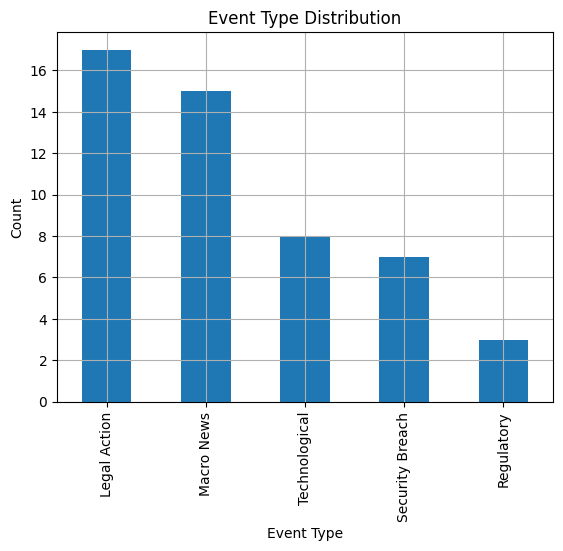

In [10]:
import matplotlib.pyplot as plt

df_articles['event_type'].value_counts().plot(kind='bar', title='Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## Step 5: Fetch Historical OHLC Data from CoinGecko

In [11]:
# Create a copy of OHLC index (daily)
all_dates = df_ohlc.index

# Get list of unique event types
event_types = df_articles['event_type'].unique()

# Initialize empty event matrix with 0s
event_matrix = pd.DataFrame(0, index=all_dates, columns=event_types)

# Fill 1 where an event happened on a date
for _, row in df_articles.iterrows():
    event_date = pd.to_datetime(row['published']).normalize()
    if event_date in event_matrix.index:
        event_matrix.at[event_date, row['event_type']] = 1

event_matrix.head()


,Legal Action,Security Breach,Macro News,Regulatory,Technological
date,,,,,
2024-05-17,1,0,0,0,0
2024-05-21,0,1,0,0,0
2024-05-25,0,0,1,0,0
2024-05-29,0,0,1,0,0
2024-06-02,1,0,0,0,0


## Step 6: Calculate 3-Day Rolling Volatility

In [12]:
# Calculate 3-day forward rolling volatility (% change from t to t+3)
df_ohlc['volatility_3d'] = (
    df_ohlc['close'].shift(-3) - df_ohlc['close']
) / df_ohlc['close'] * 100

df_ohlc['volatility_3d'] = df_ohlc['volatility_3d'].abs()  # Use absolute change
df_ohlc[['close', 'volatility_3d']].head(10)


,close,volatility_3d
date,,
2024-05-17,65261.0,4.682735
2024-05-21,71430.0,5.216296
2024-05-25,68540.0,3.859060
2024-05-29,68317.0,1.957053
2024-06-02,67704.0,1.482926
2024-06-06,71185.0,6.637634
2024-06-10,69654.0,8.013897
2024-06-14,66700.0,7.391304
2024-06-18,66460.0,8.420102


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Prepare merged DataFrame
df_analysis = df_ohlc[['volatility_3d']].copy()
df_analysis = df_analysis.merge(event_matrix, left_index=True, right_index=True, how='left')
df_analysis.fillna(0, inplace=True)
df_analysis['confounder_price'] = df_ohlc['close']  # optional confounder

# Choose one event type
treatment_col = "Regulatory"
df_analysis['treatment'] = df_analysis[treatment_col]

# Propensity score model
X = df_analysis[['confounder_price']]
treatment = df_analysis['treatment']
outcome = df_analysis['volatility_3d']

# Estimate propensity scores
model = LogisticRegression()
model.fit(X, treatment)
propensity_scores = model.predict_proba(X)[:, 1]

# Match treated to controls
treated_idx = df_analysis[treatment == 1].index
control_idx = df_analysis[treatment == 0].index

nn = NearestNeighbors(n_neighbors=1)
nn.fit(propensity_scores[treatment == 0].reshape(-1, 1))
_, indices = nn.kneighbors(propensity_scores[treatment == 1].reshape(-1, 1))
matched_control_idx = indices.flatten()


# ATE: Avg. volatility difference
treated_outcomes = outcome.loc[treated_idx].values
control_outcomes = outcome.iloc[matched_control_idx].values
ate = treated_outcomes.mean() - control_outcomes.mean()

print(f"Estimated Volatility Impact of '{treatment_col}' Events: {ate:.2f}%")


Estimated Volatility Impact of 'Regulatory' Events: -1.84%


In [14]:
event_impact = []

for event in event_matrix.columns:
    treatment = df_analysis[event]
    treated_mask = treatment == 1
    control_mask = treatment == 0

    if treated_mask.sum() == 0 or control_mask.sum() == 0:
        continue

    model = LogisticRegression()
    model.fit(df_analysis[['confounder_price']], treatment)
    scores = model.predict_proba(df_analysis[['confounder_price']])[:, 1]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(scores[control_mask].reshape(-1, 1))
    _, indices = nn.kneighbors(scores[treated_mask].reshape(-1, 1))
    matched_controls = indices.flatten()

    treated_outcomes = df_analysis.loc[treated_mask, 'volatility_3d'].values
    control_outcomes = df_analysis.loc[control_mask, 'volatility_3d'].iloc[matched_controls].values

    ate = treated_outcomes.mean() - control_outcomes.mean()
    event_impact.append((event, round(ate, 2)))


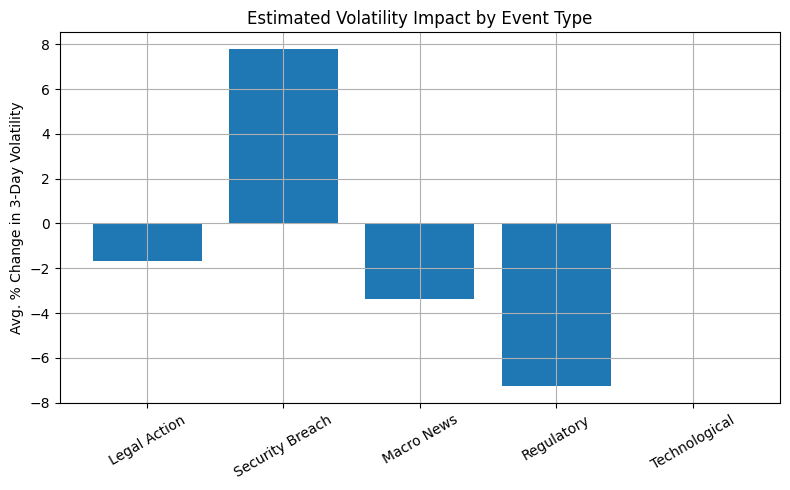

In [15]:
import matplotlib.pyplot as plt

events, ates = zip(*event_impact)
plt.figure(figsize=(8, 5))
plt.bar(events, ates)
plt.ylabel("Avg. % Change in 3-Day Volatility")
plt.title("Estimated Volatility Impact by Event Type")
plt.xticks(rotation=30)
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
from Bitcoin_utils import estimate_ate_all_events

event_impacts = estimate_ate_all_events(df_analysis, event_matrix)
print(event_impacts)


[('Legal Action', -1.68), ('Security Breach', 7.78), ('Macro News', -3.36), ('Regulatory', -7.27), ('Technological', -0.0)]


In [17]:
!pip install plotly --quiet



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import plotly.graph_objects as go

# Separate event names and ATE values
event_names = [e[0] for e in event_impacts]
ate_values = [e[1] for e in event_impacts]

# Create interactive bar chart
fig = go.Figure(data=[
    go.Bar(
        x=event_names,
        y=ate_values,
        text=[f"{val:+.2f}%" for val in ate_values],
        textposition='outside',
        marker=dict(line=dict(width=1.5, color='black'))
    )
])

fig.update_layout(
    title="Estimated Volatility Impact by Event Type",
    xaxis_title="Event Type",
    yaxis_title="Avg. % Change in 3-Day Volatility",
    yaxis=dict(tickformat=".2f"),
    template="plotly_white",
    height=500
)

fig.show()


In [19]:
!pip install -q kaleido



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [20]:
fig.write_image("volatility_event_impact.png")
fig.write_image("./volatility_event_impact.png")


In [21]:
import os
os.listdir()


['Bitcoin_API.md',
 'docker_data605_style',
 '.DS_Store',
 'Dockerfile',
 '__init__.py',
 'run_jupyter.sh',
 '__pycache__',
 'README.md',
 '.dockerignore',
 '.gitignore',
 'Bitcoin_example.ipynb',
 'iframe_figures',
 '.ipynb_checkpoints',
 'Bitcoin_API.ipynb',
 'Bitcoin_utils.py',
 'Bitcoin_example.md']